# this notebook includes the techniques to detect and remove Outliers using Z-score method.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df = pd.read_csv("placement.csv")
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [33]:
df.shape

(1000, 3)

# Plotting the features distribution and box plot to detect outliers. 

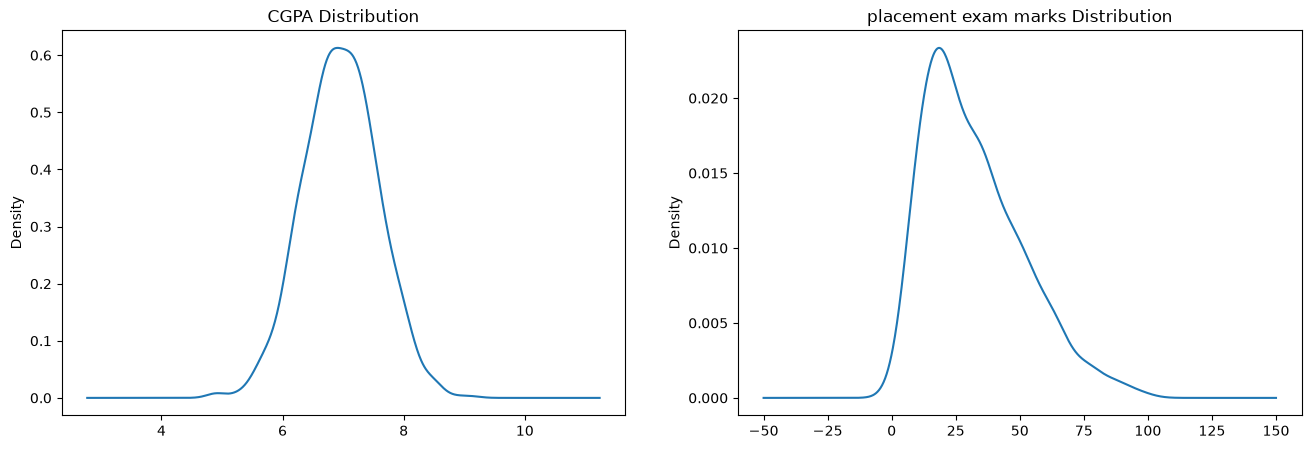

In [34]:
plt.figure(figsize=(16,5))
plt.subplot(121)
df['cgpa'].plot(kind='kde') # CGPA  is roughly normally distributred.
plt.title("CGPA Distribution")

plt.subplot(122)
df['placement_exam_marks'].plot(kind='kde') # placement exam marks is right skewed.
plt.title("placement exam marks Distribution")
plt.show()


Text(0.5, 1.0, '')

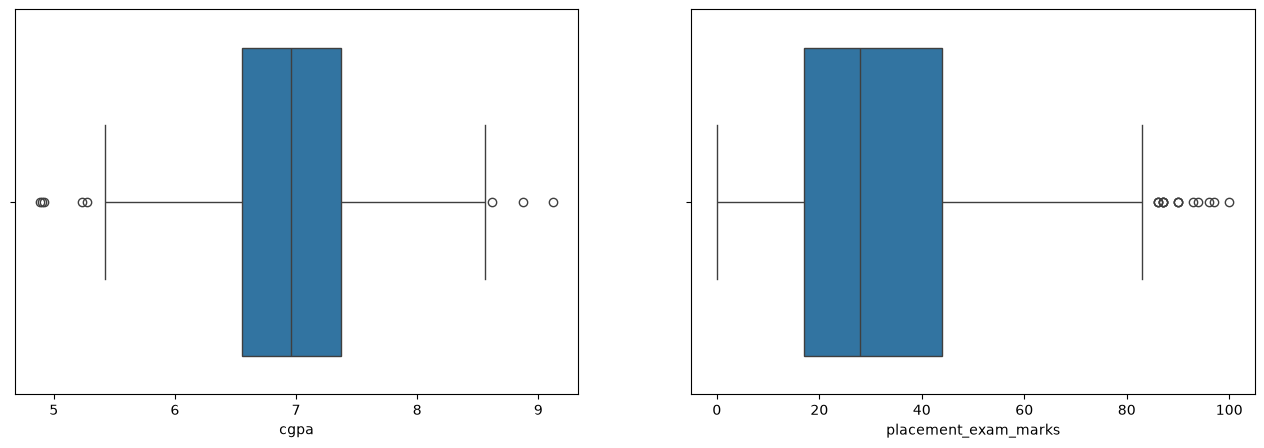

In [35]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.boxplot(x=df['cgpa'])


plt.subplot(1,2,2)
sns.boxplot(x=df['placement_exam_marks'])
plt.title("")

In [36]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

# Z-score method is  applicable to normal or close to normal distributions.
thus. we are applying it to feature 'cgpa' only.

In [37]:
print("Mean value of cgpa",df['cgpa'].mean())
print("Std value of cgpa",df['cgpa'].std())
print("Min value of cgpa",df['cgpa'].min())
print("Max value of cgpa",df['cgpa'].max())

Mean value of cgpa 6.96124
Std value of cgpa 0.6158978751323896
Min value of cgpa 4.89
Max value of cgpa 9.12


In [45]:
# Finding the boundary values
higher_limit = np.round(df['cgpa'].mean() + 3*(df['cgpa'].std()),2)
lower_limit = np.round(df['cgpa'].mean() - 3*(df['cgpa'].std()),2)


print("Highest allowed",higher_limit)
print("Lowest allowed",lower_limit)

Highest allowed 8.81
Lowest allowed 5.11


In [51]:
# finding the outliers
outliers = df[(df['cgpa'] < lower_limit )| (df['cgpa'] > higher_limit)]
outliers

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


# Trimming 

In [54]:
# approach 1
new_df = df[(df['cgpa'] >= lower_limit) & (df['cgpa']<= higher_limit)]
new_df.shape

(995, 3)

In [56]:
# approach 2 : calculating the Z-score 
df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()
df


,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
998,8.62,46.0,1,2.693239


In [59]:
df[df['cgpa_zscore'] >3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [60]:
df[df['cgpa_zscore'] < -3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [61]:
# outliers
df[(df['cgpa_zscore'] < -3) | (df['cgpa_zscore']>3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [58]:
new_df = df[(df['cgpa_zscore'] < 3) & (df['cgpa_zscore'] > -3)]
new_df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


# Capping


In [62]:
upper_limit = df['cgpa'].mean() + 3*(df['cgpa'].std())
lower_limit = df['cgpa'].mean() - 3*(df['cgpa'].std())

In [66]:
df['cgpa'] = np.where(df['cgpa'] > upper_limit,upper_limit,np.where(df['cgpa'] < lower_limit,lower_limit,df['cgpa']))
df.shape

(1000, 4)

In [67]:
df.describe()

,cgpa,placement_exam_marks,placed,cgpa_zscore
count,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,6.961499,32.225000,0.489000,-1.465494e-16
std,0.612688,19.130822,0.500129,1.000000e+00
min,5.113546,0.000000,0.000000,-3.362960e+00
25%,6.550000,17.000000,0.000000,-6.677081e-01
50%,6.960000,28.000000,0.000000,-2.013321e-03
75%,7.370000,44.000000,1.000000,6.636815e-01
max,8.808934,100.000000,1.000000,3.505062e+00
